# Test 1: Pure Cubic Perturbation Analysis

**Perturbation**: `Δa = -α₃·θ³` (single term, no lower-order contamination)

| Parameter | Value |
|-----------|-------|
| η₁ | 0 |
| η₂ | 0.1125 |
| η₃ | 0 |
| α₃ = 3·η₃/(m·l²) | 0.3375 |
| True Δa | -0.3375·θ³ |
| True ΔV | M\_scale · (α₃/4)·θ⁴ |

**Goal**: Does the pipeline give a clean single-term recovery when there are no lower-order terms to interfere?

In [77]:
import os, sys
VENV_PATH = "/Users/harshit/Documents/UWM/F25/799-IS/Lagrangian_caVAE-main/.venv/lib/python3.9/site-packages"
if VENV_PATH not in sys.path:
    sys.path.append(VENV_PATH)

_cwd = os.path.abspath('')
PROJECT_ROOT = _cwd
for _ in range(5):
    if os.path.isdir(os.path.join(PROJECT_ROOT, 'examples')):
        break
    PROJECT_ROOT = os.path.dirname(PROJECT_ROOT)
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

import torch
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from sklearn.metrics import r2_score
from pytorch_lightning import seed_everything

seed_everything(0)
%matplotlib inline

from examples.pend_lag_cavae_trainer import Model

# Patch torch.load for PyTorch 2.6+ (idempotent)
if not hasattr(torch, '_orig_load'):
    torch._orig_load = torch.load
    def _patched_load(*args, **kwargs):
        kwargs.setdefault('weights_only', False)
        return torch._orig_load(*args, **kwargs)
    torch.load = _patched_load

print(f"Project root: {PROJECT_ROOT}")

Project root: /Users/harshit/Documents/UWM/F25/799-IS/Lagrangian_caVAE-main


## Configuration

In [78]:
# ============================================================
# CONFIGURATION
# ============================================================
from matplotlib.pylab import poly


CKPT_UNPERTURBED = 'pend-lag-cavae-T_p=4-epoch=983-step=7871.ckpt'
# CKPT_PERTURBED   = 'pend-lag-cavae-T_p=4-epoch=322-step=2583.ckpt'
# CKPT_PERTURBED   = 'perturbed_re.ckpt'
# CKPT_PERTURBED   = 'pend-lag-cavae-T_p=10-epoch=547-step=0.ckpt'
# CKPT_PERTURBED     = 'poly-cubic-large-retrain.ckpt'
# CKPT_PERTURBED     = 'poly-cubic-med-retrain.ckpt'
# CKPT_PERTURBED     = '10sin2_273_retrain.ckpt'
# CKPT_PERTURBED     = '10sin4_372_retrain.ckpt'
CKPT_PERTURBED     = '10sin6_372_retrain.ckpt'


ckpt_dir = os.path.join(PROJECT_ROOT, 'results', 'pend')
ckpt = torch.load(os.path.join(ckpt_dir, CKPT_UNPERTURBED), map_location='cpu', weights_only=False)
print('T_pred:', ckpt['hyper_parameters']['T_pred'])

# ============================================================
# PERTURBATION CONFIG — change ONLY this block to switch tests
# ============================================================
# Uncomment ONE of the following configs:

# Ground-truth perturbation coefficients
ETA1, ETA2, ETA3 = 0.0, 0.0, 0.2250
M_TRUE, L_TRUE = 1.0, 1.0
ALPHA1 = 3 * ETA1 / (M_TRUE * L_TRUE**2)   # -0.1443
ALPHA2 = 3 * ETA2 / (M_TRUE * L_TRUE**2)   #  0.0339
ALPHA3 = 3 * ETA3 / (M_TRUE * L_TRUE**2)   #  0.6750

# # --- Pure cubic (eta3 = 0.2250) ---
# perturbation_config = dict(
#     name        = "Pure cubic (eta3=0.2250)",
#     # da_formula  = "-0.3375 * theta^3",
#     da_formula  = f"{-ALPHA1:.4f} * theta - {ALPHA2:.4f} * theta^2 - {ALPHA3:.4f} * theta^3",

#     # dV_formula  = "M * 0.3375/4 * theta^4",
#     dV_formula  = f"M * ({ALPHA1:.4f}/2 * theta^2 + {ALPHA2:.4f}/3 * theta^3 + {ALPHA3:.4f}/4 * theta^4)",
#     # true_da     = lambda theta, M: -0.3375 * theta**3,
#     # true_dV_raw = lambda theta, M: M * 0.3375 / 4 * theta**4,
#     true_da     = lambda theta, M: -ALPHA1 * theta - ALPHA2 * theta**2 - ALPHA3 * theta**3,
#     true_dV_raw = lambda theta, M: M * (ALPHA1 / 2 * theta**2 + ALPHA2 / 3 * theta**3 + ALPHA3 / 4 * theta**4),
#     pysr_unary      = [],
#     pysr_binary     = ['+', '-', '*'],
#     sindy_library   = lambda ps: ps.PolynomialLibrary(degree=5, include_bias=True),
#     sindy_library_v = lambda ps: ps.PolynomialLibrary(degree=6, include_bias=True),
#     poly_deg_da = 3,
#     poly_deg_dV = 4,
# )

# # --- T1: sin(2*theta), B=2.0 ---
perturbation_config = dict(
    name        = "T1: sin(6.372*theta), B=10",
    da_formula  = "10 * sin(6.372*theta)",
    dV_formula  = "M * 10/6.372 * cos(6.372*theta)",
    true_da     = lambda theta, M: 10 * np.sin(6.372 * theta),
    true_dV_raw = lambda theta, M: M * 10/6.372 * np.cos(6.372 * theta),
    pysr_unary      = ['sin', 'cos'],
    pysr_binary     = ['+', '-', '*'],
    sindy_library   = lambda ps: ps.PolynomialLibrary(degree=5, include_bias=True) + ps.FourierLibrary(n_frequencies=7),
    sindy_library_v = lambda ps: ps.PolynomialLibrary(degree=6, include_bias=True) + ps.FourierLibrary(n_frequencies=7),
    poly_deg_da = 5,
    poly_deg_dV = 6,
)

# Short alias
PC = perturbation_config

N_SAMPLES = 500
THETA_MIN, THETA_MAX = 0, 2 * np.pi
DPI = 150

print(f"Perturbation: {PC['name']}")
print(f"  da = {PC['da_formula']}")
print(f"  dV = {PC['dV_formula']}")

T_pred: 4
Perturbation: T1: sin(6.372*theta), B=10
  da = 10 * sin(6.372*theta)
  dV = M * 10/6.372 * cos(6.372*theta)


## 1. Load Models

In [79]:
ckpt_dir = os.path.join(PROJECT_ROOT, 'results', 'pend')

model_unpert = Model.load_from_checkpoint(
    os.path.join(ckpt_dir, CKPT_UNPERTURBED), map_location='cpu')
model_unpert.eval()

model_pert = Model.load_from_checkpoint(
    os.path.join(ckpt_dir, CKPT_PERTURBED), map_location='cpu')
model_pert.eval()

print("Both models loaded.")

Both models loaded.


## 2. Helper Functions

In [80]:
def extract_physics(model, theta_np):
    theta = torch.tensor(theta_np, dtype=torch.float32, requires_grad=True)
    cos_q = torch.cos(theta)
    sin_q = torch.sin(theta)
    cos_sin = torch.stack((cos_q, sin_q), dim=1)
    V = model.ode.V_net(cos_sin)
    M = model.ode.M_net(cos_sin)
    dV = torch.autograd.grad(V.sum(), theta, create_graph=False)[0]
    M_flat = M.squeeze()
    acc = -(1.0 / M_flat) * dV
    return {
        'V': V.detach().numpy().flatten(),
        'M': M_flat.detach().numpy().flatten(),
        'acc': acc.detach().numpy().flatten(),
    }

def calibrate_phase_offset(phi, a_unpert, g=10.0, l=1.0):
    K = 3 * g / (2 * l)
    best = None
    for s in [1.0, -1.0]:
        for off0 in np.linspace(0, 2*np.pi, 40):
            res = minimize(
                lambda o: np.mean((a_unpert - (-K * np.sin(s * (phi + o[0]))))**2),
                [off0], method='Nelder-Mead')
            if best is None or res.fun < best[0]:
                best = (res.fun, s, res.x[0])
    mse, sign, offset = best
    return {'offset': offset, 'sign': sign, 'mse': mse}

def phi_to_theta_phys(phi, calib):
    theta = calib['sign'] * (phi + calib['offset'])
    return ((theta + np.pi) % (2 * np.pi)) - np.pi

print("Helpers defined.")

Helpers defined.


## 3. Extract Physics & Calibrate

In [81]:
theta_range = np.linspace(THETA_MIN, THETA_MAX, N_SAMPLES)

phys_unpert = extract_physics(model_unpert, theta_range)
phys_pert = extract_physics(model_pert, theta_range)

# Calibrate phase offset
calib = calibrate_phase_offset(theta_range, phys_unpert['acc'])
print(f"Phase calibration: sign={calib['sign']:+.0f}, offset={calib['offset']:.4f} rad, MSE={calib['mse']:.4f}")

theta_phys = phi_to_theta_phys(theta_range, calib)
sort_idx = np.argsort(theta_phys)
theta_phys_sorted = theta_phys[sort_idx]
theta_gt = theta_phys_sorted  # standard alias

# Compute perturbation signals
delta_acc_sorted = (phys_pert['acc'] - phys_unpert['acc'])[sort_idx]

V_unpert_aligned = phys_unpert['V'] - phys_unpert['V'][0]
V_pert_aligned = phys_pert['V'] - phys_pert['V'][0]
delta_V_sorted = (V_pert_aligned - V_unpert_aligned)[sort_idx]
delta_V_sorted = delta_V_sorted - delta_V_sorted[0]  # zero-anchor

M_scale = np.mean(phys_pert['M'])

# Ground truth from config (GENERIC — no hardcoded formulas)
true_delta_a     = PC['true_da'](theta_gt, M_scale)
true_delta_V_raw = PC['true_dV_raw'](theta_gt, M_scale)
true_delta_V     = true_delta_V_raw - true_delta_V_raw[0]  # zero-anchored

print(f"M_scale = {M_scale:.4f}")
print(f"\nda range: [{delta_acc_sorted.min():.3f}, {delta_acc_sorted.max():.3f}]")
print(f"dV range: [{delta_V_sorted.min():.3f}, {delta_V_sorted.max():.3f}]")
print(f"\nR2(da vs GT) = {r2_score(true_delta_a, delta_acc_sorted):.4f}")
print(f"R2(dV vs GT) = {r2_score(true_delta_V, delta_V_sorted):.4f}")

Phase calibration: sign=+1, offset=2.2050 rad, MSE=0.6618
M_scale = 0.6915

da range: [-9.743, 10.506]
dV range: [-1.872, 1.413]

R2(da vs GT) = 0.7113
R2(dV vs GT) = 0.0886


## 4. Overview Plots

Compare learned V, M, and acceleration for both models, plus Δa and ΔV perturbation signals.

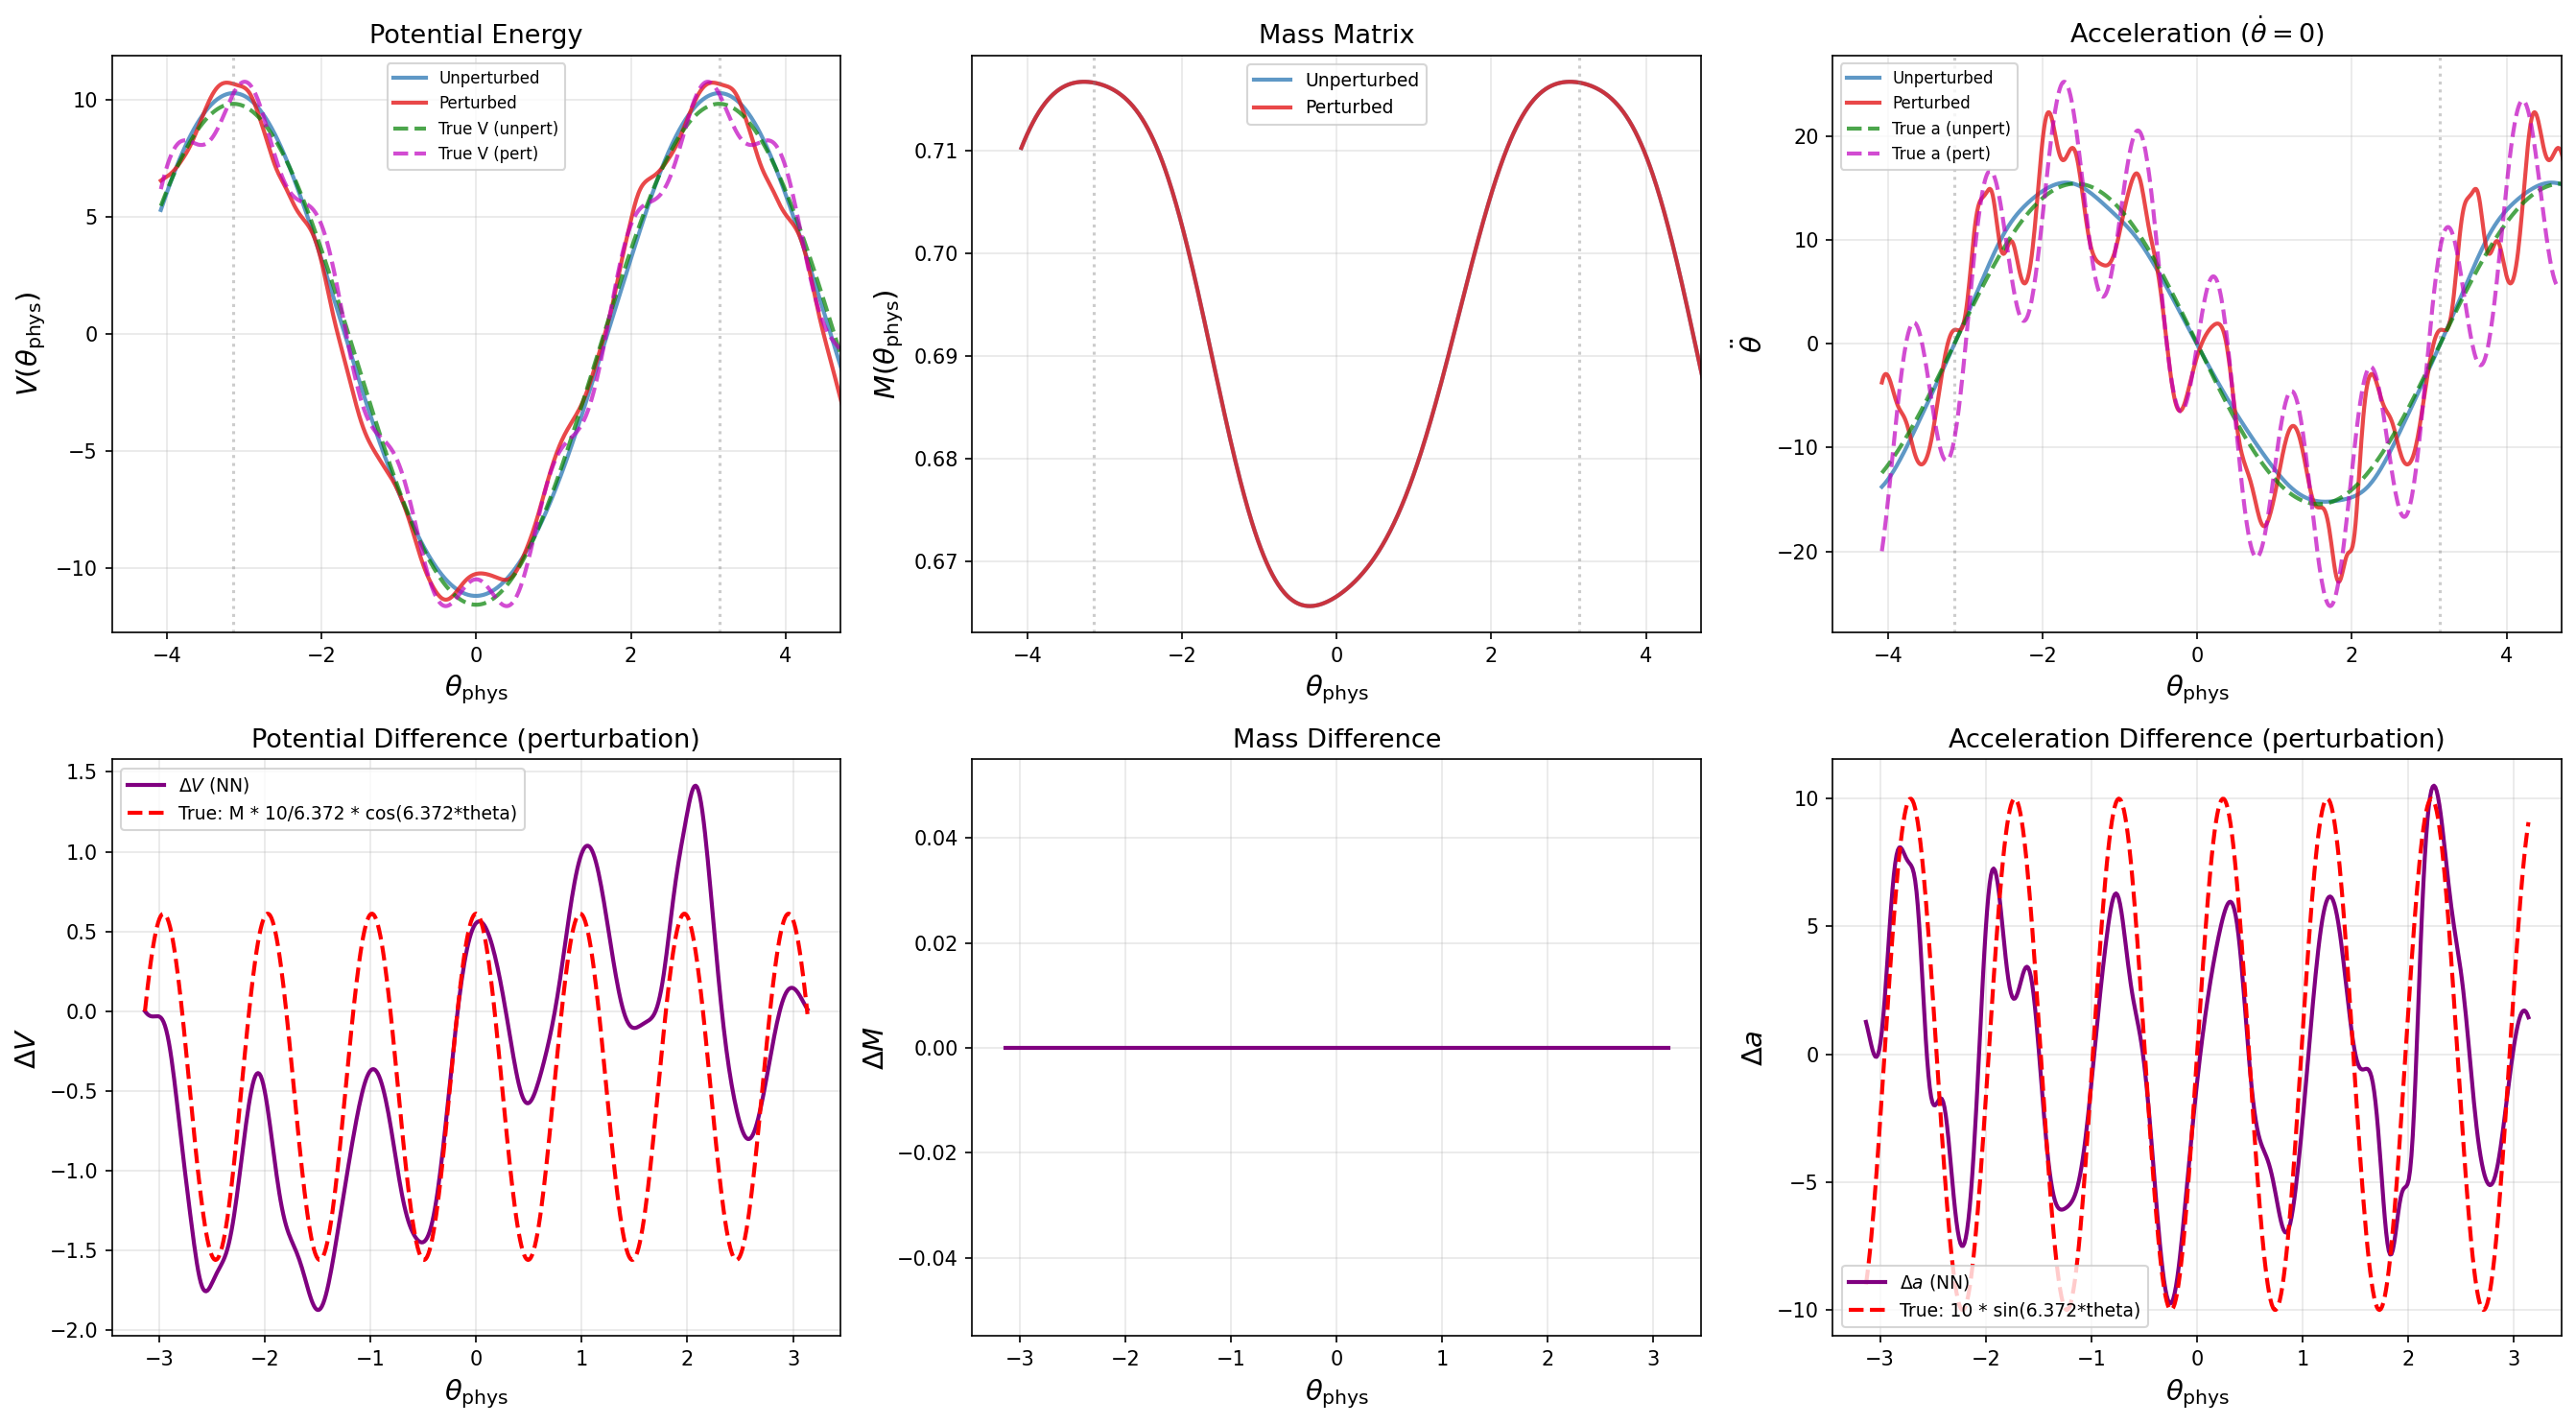

K_fitted = 15.4497 (true K = 15.0)
Row 1: Extended range, with true V and a curves (dashed green/magenta)
Row 2: Differences on [-pi, pi] where regression is performed.


In [82]:
# Extended range [-2pi, 2pi] so the peak is fully visible
phi_ext = np.linspace(-2*np.pi, 2*np.pi, 1000)
phys_unpert_ext = extract_physics(model_unpert, phi_ext)
phys_pert_ext = extract_physics(model_pert, phi_ext)

# Convert to theta_phys using same calibration
theta_phys_ext = phi_to_theta_phys(phi_ext, calib)
theta_phys_ext_unwrapped = calib['sign'] * (phi_ext + calib['offset'])
theta_center = calib['sign'] * calib['offset']
theta_phys_ext_unwrapped = theta_phys_ext_unwrapped - np.round(theta_center / (2*np.pi)) * 2*np.pi
sort_ext = np.argsort(theta_phys_ext_unwrapped)
theta_ext_sorted = theta_phys_ext_unwrapped[sort_ext]

# --- True potential in NN scale ---
# Fit K from unperturbed acceleration: a ≈ -K * sin(θ_phys)
_a_unpert_for_fit = phys_unpert['acc'][sort_idx]
_res = minimize(
    lambda p: np.mean((_a_unpert_for_fit - (-p[0] * np.sin(theta_gt)))**2),
    [15.0], method='Nelder-Mead')
K_fitted = _res.x[0]

# Clip to plot range [-1.5pi, 1.5pi] to match xlim
_xlim = 1.5 * np.pi
_mask = (theta_ext_sorted >= -_xlim) & (theta_ext_sorted <= _xlim)
_theta_clip = theta_ext_sorted[_mask]

V_true_unpert_clip = -M_scale * K_fitted * np.cos(_theta_clip)
V_learned_unpert_clip = phys_unpert_ext['V'].flatten()[sort_ext][_mask]
V_true_unpert_clip += np.mean(V_learned_unpert_clip) - np.mean(V_true_unpert_clip)
V_true_pert_clip = V_true_unpert_clip + PC['true_dV_raw'](_theta_clip, M_scale)

a_true_unpert_clip = -K_fitted * np.sin(_theta_clip)
a_true_pert_clip = a_true_unpert_clip + PC['true_da'](_theta_clip, M_scale)

fig, axes = plt.subplots(2, 3, figsize=(18, 10), dpi=DPI)

labels = ['Unperturbed', 'Perturbed']
colors = ['#377eb8', '#e41a1c']
data_ext = [phys_unpert_ext, phys_pert_ext]

# Row 1: Raw V, M, acc on extended range
for i, (key, ylabel, title) in enumerate([
    ('V',   r'$V(\theta_{\mathrm{phys}})$',          'Potential Energy'),
    ('M',   r'$M(\theta_{\mathrm{phys}})$',          'Mass Matrix'),
    ('acc', r'$\ddot{\theta}$',  r'Acceleration ($\dot{\theta}=0$)'),
]):
    for d, label, c in zip(data_ext, labels, colors):
        axes[0, i].plot(theta_ext_sorted, d[key][sort_ext], color=c, lw=2, label=label, alpha=0.8)
    axes[0, i].set_xlabel(r'$\theta_{\mathrm{phys}}$', fontsize=14)
    axes[0, i].set_ylabel(ylabel, fontsize=14)
    axes[0, i].set_title(title, fontsize=13)
    axes[0, i].legend(fontsize=9)
    axes[0, i].grid(True, alpha=0.3)
    axes[0, i].axvline(x=-np.pi, color='gray', ls=':', alpha=0.4)
    axes[0, i].axvline(x=np.pi, color='gray', ls=':', alpha=0.4)
for i in range(3):
    axes[0, i].set_xlim(-_xlim, _xlim)

# Add true V curves
axes[0, 0].plot(_theta_clip, V_true_unpert_clip, 'g--', lw=2, alpha=0.7, label='True V (unpert)')
axes[0, 0].plot(_theta_clip, V_true_pert_clip, 'm--', lw=2, alpha=0.7, label='True V (pert)')
axes[0, 0].legend(fontsize=8)

# Add true acceleration curves
axes[0, 2].plot(_theta_clip, a_true_unpert_clip, 'g--', lw=2, alpha=0.7, label='True a (unpert)')
axes[0, 2].plot(_theta_clip, a_true_pert_clip, 'm--', lw=2, alpha=0.7, label='True a (pert)')
axes[0, 2].legend(fontsize=8)

# Row 2: Differences on [-pi, pi] (regression data)
M_diff = (phys_pert['M'] - phys_unpert['M'])[sort_idx]

ax = axes[1, 0]
ax.plot(theta_gt, delta_V_sorted, 'purple', lw=2, label=r'$\Delta V$ (NN)')
ax.plot(theta_gt, true_delta_V, 'r--', lw=2, label=f'True: {PC["dV_formula"]}')
ax.set_xlabel(r'$\theta_{\mathrm{phys}}$', fontsize=14)
ax.set_ylabel(r'$\Delta V$', fontsize=14)
ax.set_title('Potential Difference (perturbation)', fontsize=13)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

ax = axes[1, 1]
ax.plot(theta_gt, M_diff, 'purple', lw=2)
ax.set_xlabel(r'$\theta_{\mathrm{phys}}$', fontsize=14)
ax.set_ylabel(r'$\Delta M$', fontsize=14)
ax.set_title('Mass Difference', fontsize=13)
ax.grid(True, alpha=0.3)

ax = axes[1, 2]
ax.plot(theta_gt, delta_acc_sorted, 'purple', lw=2, label=r'$\Delta a$ (NN)')
ax.plot(theta_gt, true_delta_a, 'r--', lw=2, label=f'True: {PC["da_formula"]}')
ax.set_xlabel(r'$\theta_{\mathrm{phys}}$', fontsize=14)
ax.set_ylabel(r'$\Delta a$', fontsize=14)
ax.set_title('Acceleration Difference (perturbation)', fontsize=13)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
safe_name = PC["name"].replace(" ", "_").replace("*", "x").replace(":", "_").replace(",", "").replace("(", "").replace(")", "")
fig.savefig(os.path.join(PROJECT_ROOT, 'results', 'pend', 'sin_perturbations', f'perturbation_{safe_name}.png'), bbox_inches='tight')
plt.show()

print(f"K_fitted = {K_fitted:.4f} (true K = 15.0)")
print("Row 1: Extended range, with true V and a curves (dashed green/magenta)")
print("Row 2: Differences on [-pi, pi] where regression is performed.")

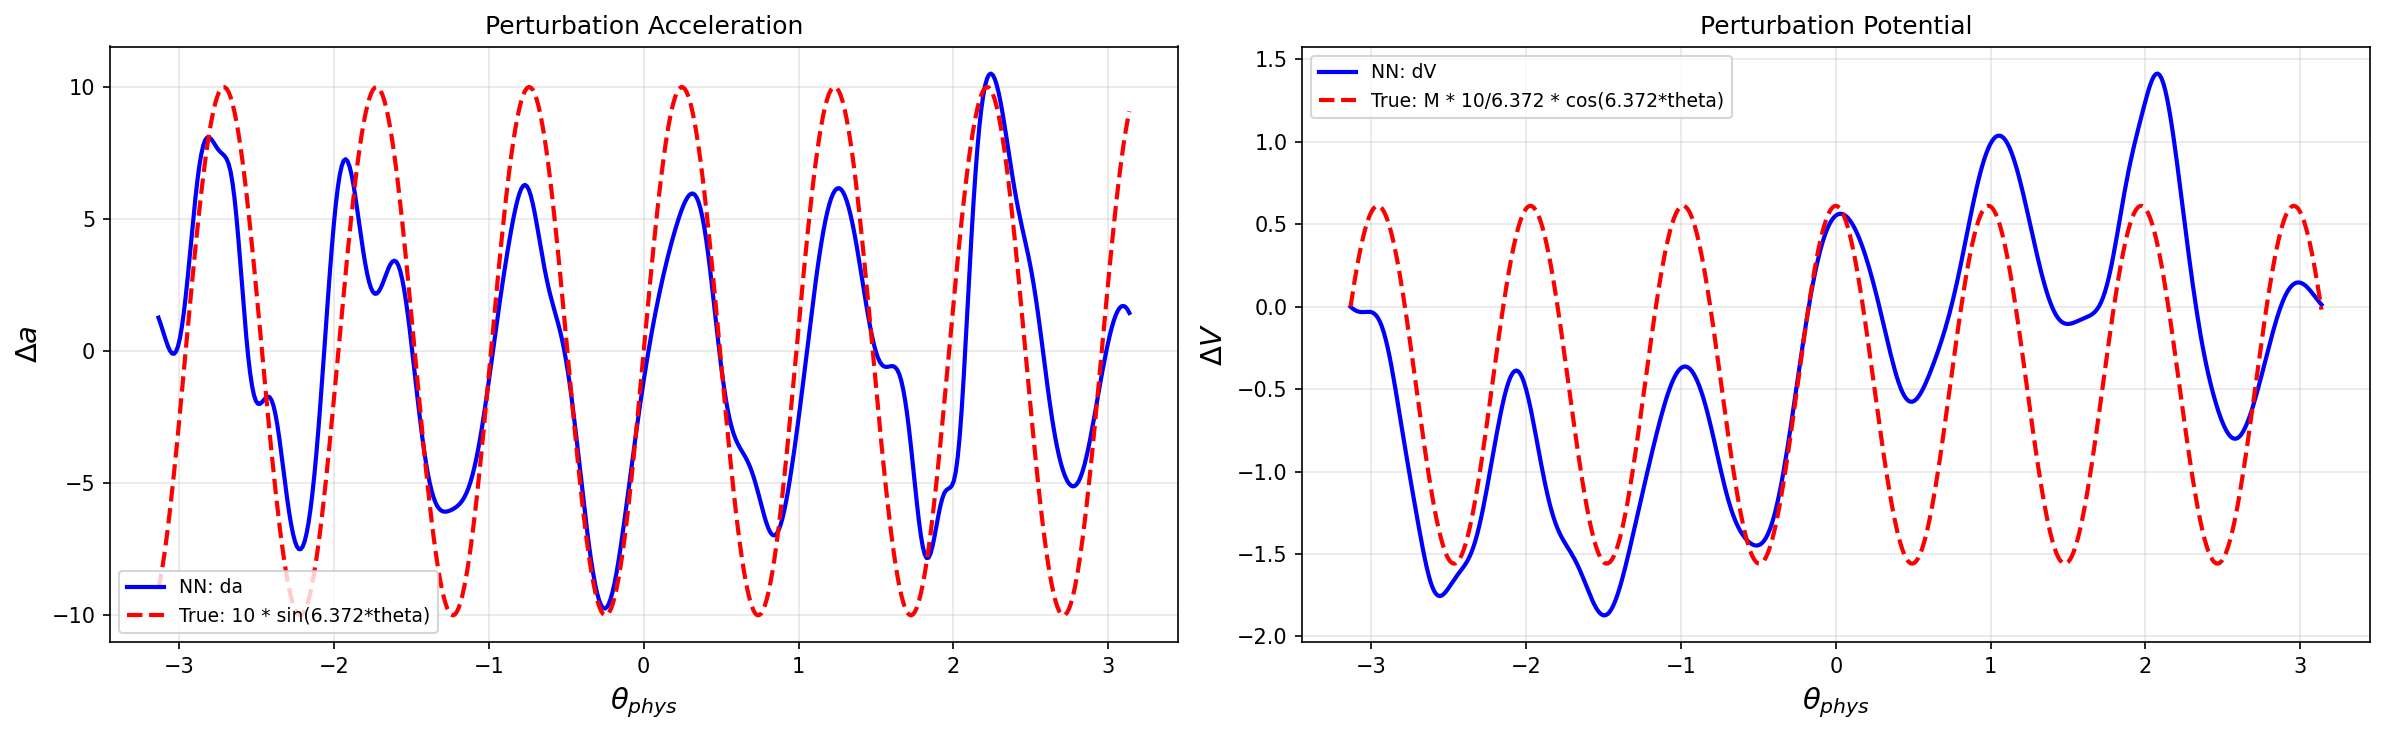

In [83]:
# Perturbation signals: da and dV
fig, axes = plt.subplots(1, 2, figsize=(16, 5), dpi=DPI)

ax = axes[0]
ax.plot(theta_gt, delta_acc_sorted, 'b-', lw=2, label='NN: da')
ax.plot(theta_gt, true_delta_a, 'r--', lw=2, label=f'True: {PC["da_formula"]}')
ax.set_xlabel(r'$\theta_{phys}$', fontsize=14)
ax.set_ylabel(r'$\Delta a$', fontsize=14)
ax.set_title('Perturbation Acceleration')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

ax = axes[1]
ax.plot(theta_gt, delta_V_sorted, 'b-', lw=2, label='NN: dV')
ax.plot(theta_gt, true_delta_V, 'r--', lw=2, label=f'True: {PC["dV_formula"]}')
ax.set_xlabel(r'$\theta_{phys}$', fontsize=14)
ax.set_ylabel(r'$\Delta V$', fontsize=14)
ax.set_title('Perturbation Potential')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 5. Polynomial Regression

In [84]:
print("=" * 65)
print(f"POLYNOMIAL REGRESSION — {PC['name']}")
print("=" * 65)

# --- Fit da ---
print(f"\n--- Polynomial fit to da ---")
print(f"True: da = {PC['da_formula']}")

for deg in range(PC['poly_deg_da'], PC['poly_deg_da'] + 3):
    coeffs = np.polyfit(theta_gt, delta_acc_sorted, deg)
    pred = np.polyval(coeffs, theta_gt)
    r2 = 1 - np.sum((delta_acc_sorted - pred)**2) / np.sum((delta_acc_sorted - delta_acc_sorted.mean())**2)
    print(f"\n  Degree {deg} (R2 = {r2:.6f}):")
    for i, c in enumerate(coeffs):
        power = deg - i
        if abs(c) > 1e-6:
            print(f"    theta^{power}: {c:+.6f}")

# --- Fit dV ---
print(f"\n\n--- Polynomial fit to dV ---")
print(f"True: dV = {PC['dV_formula']}")

for deg in range(PC['poly_deg_dV'], PC['poly_deg_dV'] + 3):
    coeffs = np.polyfit(theta_gt, delta_V_sorted, deg)
    pred = np.polyval(coeffs, theta_gt)
    r2 = 1 - np.sum((delta_V_sorted - pred)**2) / np.sum((delta_V_sorted - delta_V_sorted.mean())**2)
    print(f"\n  Degree {deg} (R2 = {r2:.6f}):")
    for i, c in enumerate(coeffs):
        power = deg - i
        if abs(c) > 1e-6:
            print(f"    theta^{power}: {c:+.6f}")

POLYNOMIAL REGRESSION — T1: sin(6.372*theta), B=10

--- Polynomial fit to da ---
True: da = 10 * sin(6.372*theta)

  Degree 5 (R2 = 0.056995):
    theta^5: -0.025495
    theta^4: -0.037691
    theta^3: +0.154534
    theta^2: +0.616320
    theta^1: -0.001702
    theta^0: -1.299018

  Degree 6 (R2 = 0.057745):
    theta^6: -0.007222
    theta^5: -0.025419
    theta^4: +0.059525
    theta^3: +0.153839
    theta^2: +0.296378
    theta^1: -0.000632
    theta^0: -1.148630

  Degree 7 (R2 = 0.063660):
    theta^7: +0.012877
    theta^6: -0.007343
    theta^5: -0.230658
    theta^4: +0.060948
    theta^3: +1.074281
    theta^2: +0.292160
    theta^1: -1.009948
    theta^0: -1.146969


--- Polynomial fit to dV ---
True: dV = M * 10/6.372 * cos(6.372*theta)

  Degree 6 (R2 = 0.617598):
    theta^6: +0.006116
    theta^5: +0.002299
    theta^4: -0.069261
    theta^3: -0.107991
    theta^2: +0.145483
    theta^1: +0.812263
    theta^0: -0.347962

  Degree 7 (R2 = 0.617992):
    theta^7: +0.000559


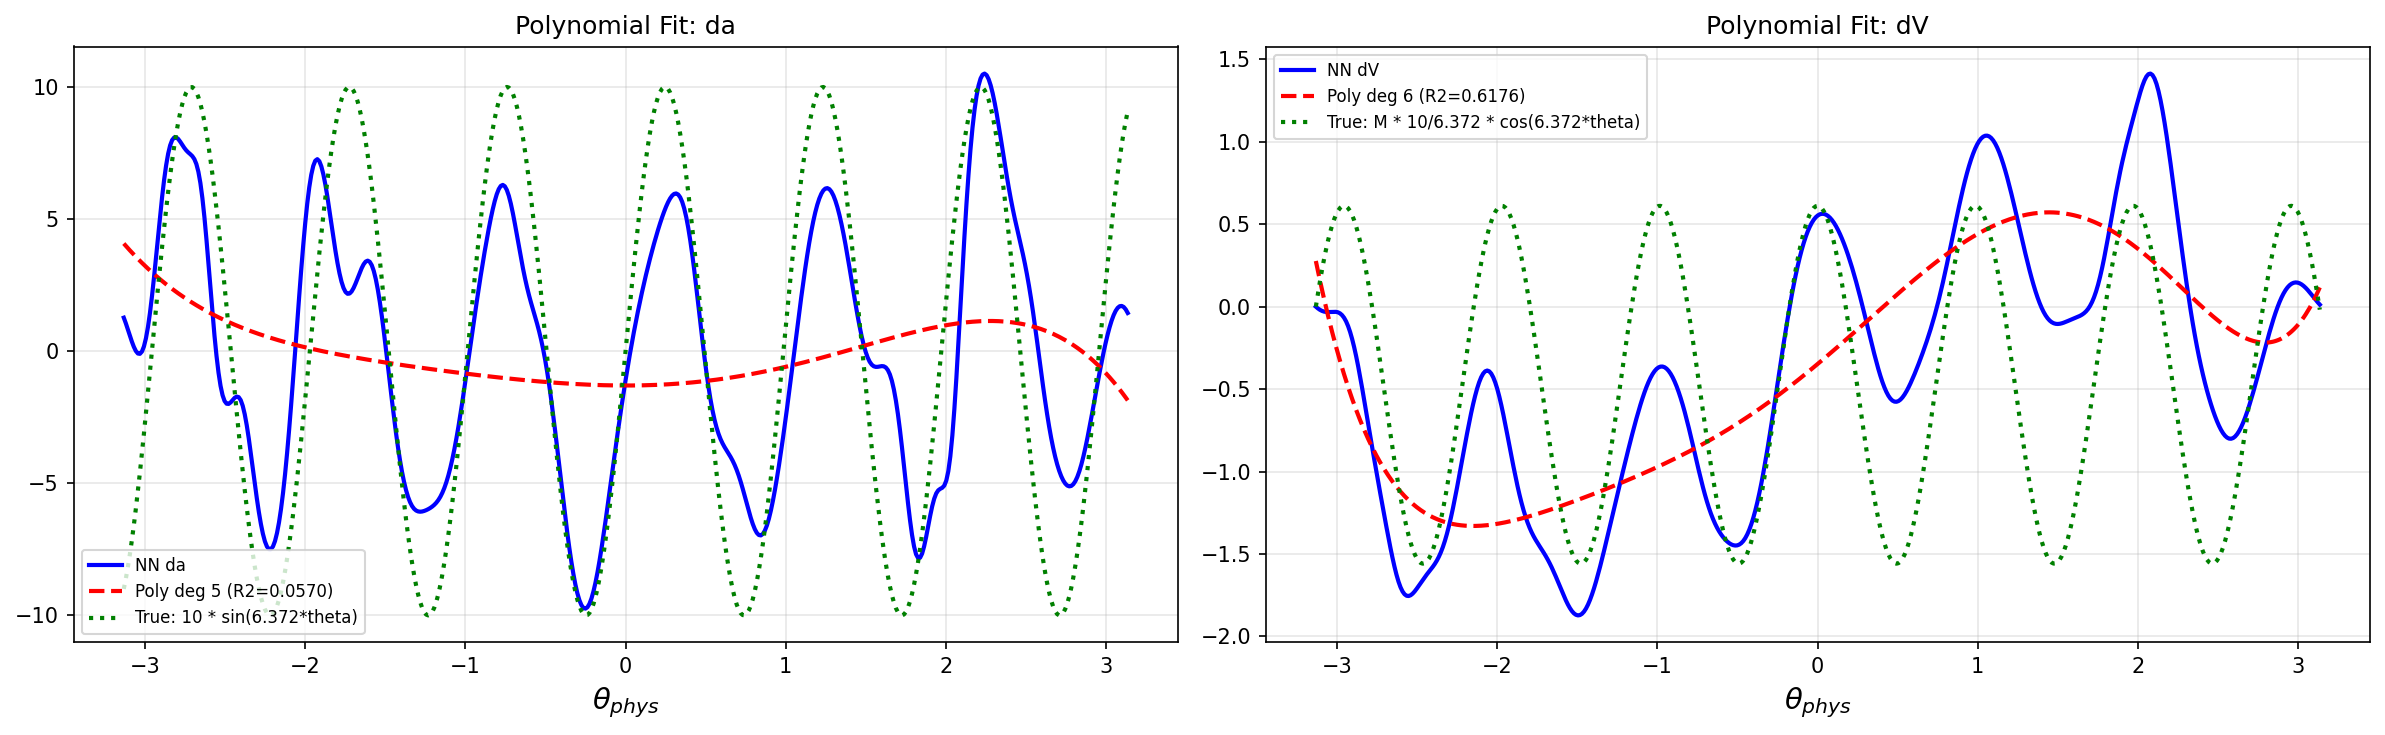

In [85]:
# Plot best polynomial fits
fig, axes = plt.subplots(1, 2, figsize=(16, 5), dpi=DPI)

deg_da = PC['poly_deg_da']
coeffs_da = np.polyfit(theta_gt, delta_acc_sorted, deg_da)
poly_da = np.polyval(coeffs_da, theta_gt)
r2_da = 1 - np.sum((delta_acc_sorted - poly_da)**2) / np.sum((delta_acc_sorted - delta_acc_sorted.mean())**2)

ax = axes[0]
ax.plot(theta_gt, delta_acc_sorted, 'b-', lw=2, label='NN da')
ax.plot(theta_gt, poly_da, 'r--', lw=2, label=f'Poly deg {deg_da} (R2={r2_da:.4f})')
ax.plot(theta_gt, true_delta_a, 'g:', lw=2, label=f'True: {PC["da_formula"]}')
ax.set_xlabel(r'$\theta_{phys}$', fontsize=14)
ax.set_title('Polynomial Fit: da')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

deg_dv = PC['poly_deg_dV']
coeffs_dv = np.polyfit(theta_gt, delta_V_sorted, deg_dv)
poly_dv = np.polyval(coeffs_dv, theta_gt)
r2_dv = 1 - np.sum((delta_V_sorted - poly_dv)**2) / np.sum((delta_V_sorted - delta_V_sorted.mean())**2)

ax = axes[1]
ax.plot(theta_gt, delta_V_sorted, 'b-', lw=2, label='NN dV')
ax.plot(theta_gt, poly_dv, 'r--', lw=2, label=f'Poly deg {deg_dv} (R2={r2_dv:.4f})')
ax.plot(theta_gt, true_delta_V, 'g:', lw=2, label=f'True: {PC["dV_formula"]}')
ax.set_xlabel(r'$\theta_{phys}$', fontsize=14)
ax.set_title('Polynomial Fit: dV')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 6. SINDy

In [86]:
import pysindy as ps

print("=" * 65)
print(f"SINDy — {PC['name']}")
print("=" * 65)

X_sindy = theta_gt.reshape(-1, 1)
thresholds = np.logspace(-3, 0, 20)

# --- da ---
print(f"\n--- SINDy on da ---")
print(f"True: da = {PC['da_formula']}")
y_da = delta_acc_sorted.reshape(-1, 1)
lib_da = PC['sindy_library'](ps)

results_da = []
for thr in thresholds:
    opt = ps.STLSQ(threshold=thr, alpha=1e-5, max_iter=50)
    m = ps.SINDy(feature_library=lib_da, optimizer=opt)
    m.fit(X_sindy, t=1, x_dot=y_da, feature_names=['theta'])
    pred = np.array(m.predict(X_sindy))
    r2 = 1 - np.sum((y_da - pred)**2) / np.sum((y_da - y_da.mean())**2)
    coef = m.coefficients().flatten()
    n_act = np.sum(np.abs(coef) > 1e-10)
    results_da.append({
        'threshold': thr, 'r2': r2, 'n_active': n_act,
        'coeffs': coef, 'model': m, 'equations': m.equations()
    })

cands = [r for r in results_da if r['n_active'] <= 4 and r['r2'] > 0.5]
best_da = max(cands if cands else results_da, key=lambda r: r['r2'])

print(f"\nBest SINDy (da): R2 = {best_da['r2']:.4f}, {best_da['n_active']} active terms")
print(f"  Equation: {best_da['equations'][0]}")
print(f"  Threshold: {best_da['threshold']:.4f}")

feature_names = best_da['model'].get_feature_names()
print(f"\n  {'Feature':<20} {'Coeff':>12}")
print(f"  {'-'*34}")
for fname, coeff in zip(feature_names, best_da['coeffs']):
    if abs(coeff) > 1e-10:
        print(f"  {fname:<20} {coeff:>12.6f}")

# --- dV ---
print(f"\n\n--- SINDy on dV ---")
print(f"True: dV = {PC['dV_formula']}")
y_dv = delta_V_sorted.reshape(-1, 1)
lib_dv = PC['sindy_library_v'](ps)

results_dv = []
for thr in thresholds:
    opt = ps.STLSQ(threshold=thr, alpha=1e-5, max_iter=50)
    m = ps.SINDy(feature_library=lib_dv, optimizer=opt)
    m.fit(X_sindy, t=1, x_dot=y_dv, feature_names=['theta'])
    pred = np.array(m.predict(X_sindy))
    r2 = 1 - np.sum((y_dv - pred)**2) / np.sum((y_dv - y_dv.mean())**2)
    coef = m.coefficients().flatten()
    n_act = np.sum(np.abs(coef) > 1e-10)
    results_dv.append({
        'threshold': thr, 'r2': r2, 'n_active': n_act,
        'coeffs': coef, 'model': m, 'equations': m.equations()
    })

cands = [r for r in results_dv if r['n_active'] <= 5 and r['r2'] > 0.5]
best_dv = max(cands if cands else results_dv, key=lambda r: r['r2'])

print(f"\nBest SINDy (dV): R2 = {best_dv['r2']:.4f}, {best_dv['n_active']} active terms")
print(f"  Equation: {best_dv['equations'][0]}")
print(f"  Threshold: {best_dv['threshold']:.4f}")

feature_names = best_dv['model'].get_feature_names()
print(f"\n  {'Feature':<20} {'Coeff':>12}")
print(f"  {'-'*34}")
for fname, coeff in zip(feature_names, best_dv['coeffs']):
    if abs(coeff) > 1e-10:
        print(f"  {fname:<20} {coeff:>12.6f}")

SINDy — T1: sin(6.372*theta), B=10

--- SINDy on da ---
True: da = 10 * sin(6.372*theta)

Best SINDy (da): R2 = 0.9239, 20 active terms
  Equation: -150.818 1 + -33680.216 theta + 65.587 theta^2 + 4913.787 theta^3 + -3.335 theta^4 + -152.115 theta^5 + 35421.545 sin(1 theta) + 157.828 cos(1 theta) + -1005.357 sin(2 theta) + -9.676 cos(2 theta) + 110.413 sin(3 theta) + 1.864 cos(3 theta) + -18.381 sin(4 theta) + -0.848 cos(4 theta) + 2.636 sin(5 theta) + 0.278 cos(5 theta) + 6.257 sin(6 theta) + -0.524 cos(6 theta) + 0.360 sin(7 theta) + -0.327 cos(7 theta)
  Threshold: 0.0010

  Feature                     Coeff
  ----------------------------------
  1                     -150.818493
  theta                -33680.215589
  theta^2                 65.587032
  theta^3               4913.786538
  theta^4                 -3.335011
  theta^5               -152.115256
  sin(1 theta)         35421.544847
  cos(1 theta)           157.828105
  sin(2 theta)         -1005.357219
  cos(2 theta)     

/Users/harshit/miniconda3/envs/lagrangian_clean/lib/python3.9/site-packages/pysindy/optimizers/stlsq.py:224: UserWarning: Sparsity parameter is too big (1.0) and eliminated all coefficients
  warnings.warn(



Best SINDy (dV): R2 = 0.9926, 21 active terms
  Equation: -59684.097 1 + 2043.152 theta + 28739.191 theta^2 + -296.855 theta^3 + -2092.938 theta^4 + 9.103 theta^5 + 43.030 theta^6 + -2152.432 sin(1 theta) + 60502.117 cos(1 theta) + 64.327 sin(2 theta) + -877.417 cos(2 theta) + -7.840 sin(3 theta) + 67.299 cos(3 theta) + 1.702 sin(4 theta) + -9.516 cos(4 theta) + -0.470 sin(5 theta) + 1.659 cos(5 theta) + 0.193 sin(6 theta) + 0.412 cos(6 theta) + -0.009 sin(7 theta) + 0.091 cos(7 theta)
  Threshold: 0.0010

  Feature                     Coeff
  ----------------------------------
  1                    -59684.097283
  theta                 2043.151900
  theta^2              28739.191260
  theta^3               -296.854910
  theta^4              -2092.937649
  theta^5                  9.102993
  theta^6                 43.030012
  sin(1 theta)         -2152.432426
  cos(1 theta)         60502.116920
  sin(2 theta)            64.327409
  cos(2 theta)          -877.417311
  sin(3 theta)   

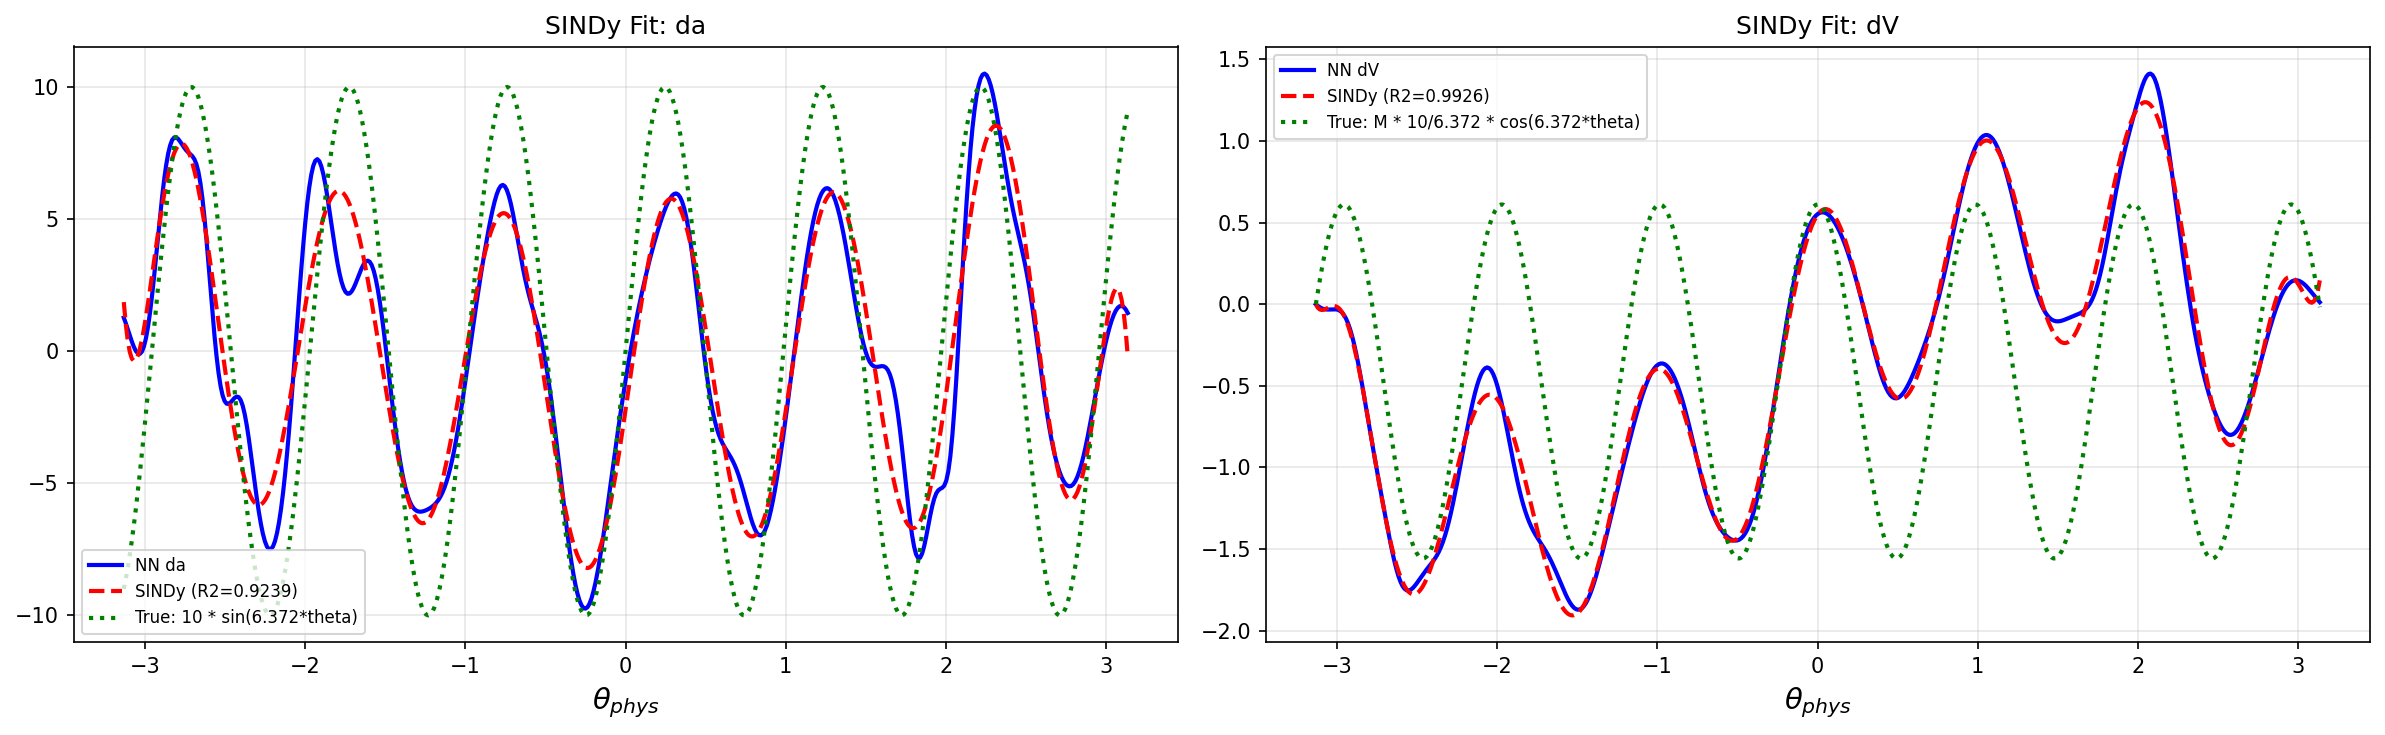

In [87]:
# SINDy fit plots
fig, axes = plt.subplots(1, 2, figsize=(16, 5), dpi=DPI)

pred_da_s = np.array(best_da['model'].predict(X_sindy)).flatten()
ax = axes[0]
ax.plot(theta_gt, delta_acc_sorted, 'b-', lw=2, label='NN da')
ax.plot(theta_gt, pred_da_s, 'r--', lw=2, label=f'SINDy (R2={best_da["r2"]:.4f})')
ax.plot(theta_gt, true_delta_a, 'g:', lw=2, label=f'True: {PC["da_formula"]}')
ax.set_xlabel(r'$\theta_{phys}$', fontsize=14)
ax.set_title('SINDy Fit: da')
ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

pred_dv_s = np.array(best_dv['model'].predict(X_sindy)).flatten()
ax = axes[1]
ax.plot(theta_gt, delta_V_sorted, 'b-', lw=2, label='NN dV')
ax.plot(theta_gt, pred_dv_s, 'r--', lw=2, label=f'SINDy (R2={best_dv["r2"]:.4f})')
ax.plot(theta_gt, true_delta_V, 'g:', lw=2, label=f'True: {PC["dV_formula"]}')
ax.set_xlabel(r'$\theta_{phys}$', fontsize=14)
ax.set_title('SINDy Fit: dV')
ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 7. PySR (Symbolic Regression)

Genetic-programming symbolic regression on Δa and ΔV.

PySR — T1: sin(6.372*theta), B=10

--- PySR on da ---


/Users/harshit/miniconda3/envs/lagrangian_clean/lib/python3.9/site-packages/pysr/sr.py:2811: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(
/Users/harshit/miniconda3/envs/lagrangian_clean/lib/python3.9/site-packages/pysr/sr.py:1873: UserWarning: Note: Setting `random_state` without also setting `deterministic=True` and `parallelism='serial'` will result in non-deterministic searches.
  warnings.warn(
[ Info: Started!



Expressions evaluated per second: 3.580e+05
Progress: 675 / 9000 total iterations (7.500%)
════════════════════════════════════════════════════════════════════════════════════════════════════
───────────────────────────────────────────────────────────────────────────────────────────────────
Complexity  Loss       Score      Equation
1           2.367e+01  0.000e+00  y = -0.0048866
3           2.359e+01  1.534e-03  y = theta * -0.14849
4           1.784e+01  2.797e-01  y = sin(theta * 6.1569)
6           3.271e+00  8.481e-01  y = sin(theta * 6.1664) * 6.4566
8           3.172e+00  1.530e-02  y = sin((theta * 6.1667) + -0.067946) * 6.4726
9           2.496e+00  2.399e-01  y = (sin(theta * 6.1661) * 6.4536) - cos(theta)
11          2.372e+00  2.545e-02  y = (sin((theta + -0.012356) * 6.1674) * 6.4738) - cos(the...
                                      ta)
13          2.328e+00  9.411e-03  y = (sin(6.1677 * (-0.012333 + theta)) * 6.4749) - (1.3561...
                                      

[ Info: Final population:
[ Info: Results saved to:


───────────────────────────────────────────────────────────────────────────────────────────────────
Complexity  Loss       Score      Equation
1           2.367e+01  0.000e+00  y = -0.0048866
3           2.359e+01  1.534e-03  y = theta * -0.14849
4           1.784e+01  2.797e-01  y = sin(theta * 6.1569)
6           3.271e+00  8.481e-01  y = sin(theta * 6.1664) * 6.4566
8           3.172e+00  1.531e-02  y = sin((theta * -6.1667) + -3.0737) * 6.4717
9           2.496e+00  2.399e-01  y = (sin(theta * -6.1662) * -6.4538) - cos(theta)
11          2.372e+00  2.545e-02  y = (sin((theta + -0.012356) * 6.1674) * 6.4738) - cos(the...
                                      ta)
13          2.326e+00  9.753e-03  y = (sin((theta * 6.1677) + -0.078686) * 6.4743) - (cos(th...
                                      eta) * 1.3034)
14          2.070e+00  1.166e-01  y = ((sin(theta * 6.1558) * 6.4578) - sin(theta * 10.278))...
                                       - cos(theta)
15          2.069e+00  3.328e

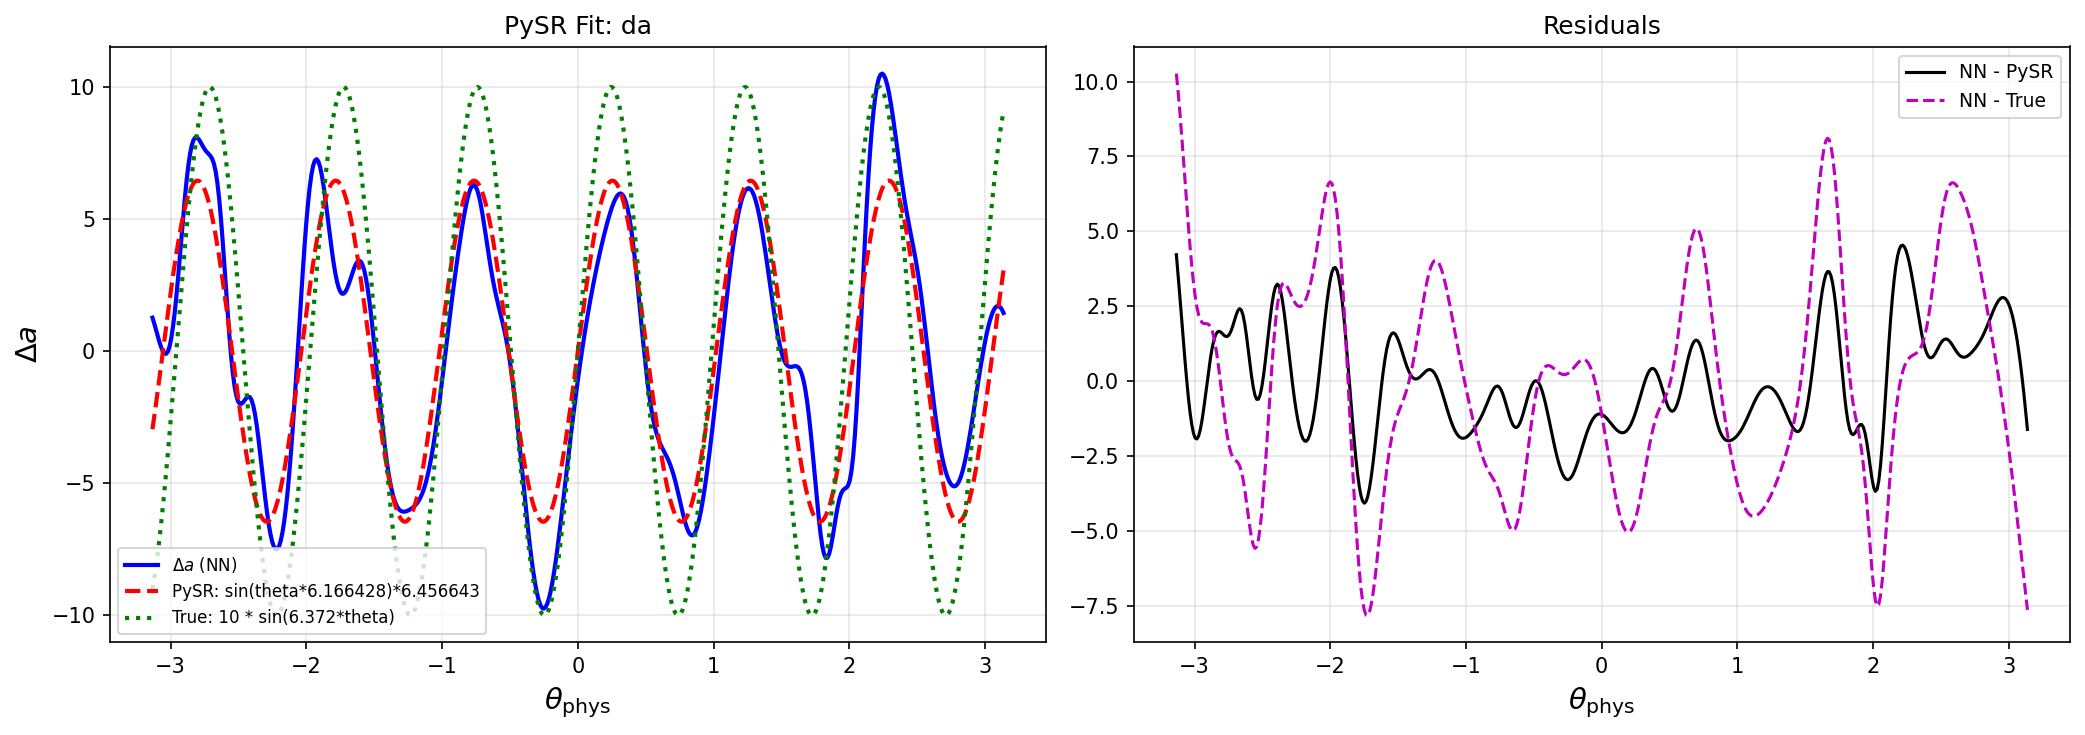


PySR equation table:
    complexity       loss                                                                                                             equation
0            1  23.667192                                                                                                        -0.0048866104
1            3  23.594627                                                                                                  theta * -0.14848612
2            4  17.837324                                                                                               sin(theta * 6.1568704)
3            6   3.270973                                                                                     sin(theta * 6.166428) * 6.456643
4            8   3.172364                                                                     sin((theta * -6.166666) + -3.0736744) * 6.471747
5            9   2.495839                                                                    (sin(theta * -6.1662083) * 

In [88]:
from pysr import PySRRegressor

print("=" * 65)
print(f"PySR — {PC['name']}")
print("=" * 65)

X_fit = theta_gt.reshape(-1, 1)

print("\n--- PySR on da ---")
sr_da = PySRRegressor(
    niterations=300,
    binary_operators=PC['pysr_binary'],
    unary_operators=PC['pysr_unary'],
    denoise=False,
    model_selection='best',
    maxsize=20,
    parsimony=0.005,
    populations=30,
    population_size=50,
    ncycles_per_iteration=550,
    weight_optimize=0.001,
    adaptive_parsimony_scaling=1000,
    random_state=42,
    procs=4,
    temp_equation_file=True,
)
sr_da.fit(X_fit, delta_acc_sorted, variable_names=['theta'])

# Select best by max score
eqs_da = sr_da.equations_
scores_da = eqs_da['score'].values.astype(float)
best_idx_da = eqs_da.index[np.argmax(scores_da)]
expr_da = sr_da.sympy(index=best_idx_da)
pred_da_pysr = sr_da.predict(X_fit, index=best_idx_da)

print(f"\nBest expression: {expr_da}")
print(f"Complexity: {eqs_da.loc[best_idx_da, 'complexity']}")

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5), dpi=DPI)

axes[0].plot(theta_gt, delta_acc_sorted, 'b-', lw=2, label=r'$\Delta a$ (NN)')
axes[0].plot(theta_gt, pred_da_pysr, 'r--', lw=2, label=f'PySR: {expr_da}')
axes[0].plot(theta_gt, true_delta_a, 'g:', lw=2, label=f'True: {PC["da_formula"]}')
axes[0].set_xlabel(r'$\theta_{\mathrm{phys}}$', fontsize=14)
axes[0].set_ylabel(r'$\Delta a$', fontsize=14)
axes[0].set_title('PySR Fit: da')
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.3)

axes[1].plot(theta_gt, delta_acc_sorted - pred_da_pysr, 'k-', lw=1.5, label='NN - PySR')
axes[1].plot(theta_gt, delta_acc_sorted - true_delta_a, 'm--', lw=1.5, label='NN - True')
axes[1].set_xlabel(r'$\theta_{\mathrm{phys}}$', fontsize=14)
axes[1].set_title('Residuals')
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nPySR equation table:")
print(sr_da.equations_[['complexity', 'loss', 'equation']].to_string())

PySR on dV — T1: sin(6.372*theta), B=10

Expressions evaluated per second: 2.470e+05
Progress: 498 / 9000 total iterations (5.533%)
════════════════════════════════════════════════════════════════════════════════════════════════════
───────────────────────────────────────────────────────────────────────────────────────────────────
Complexity  Loss       Score      Equation
1           6.682e-01  0.000e+00  y = -0.37767
2           4.317e-01  4.369e-01  y = sin(theta)
3           4.250e-01  1.556e-02  y = sin(sin(theta))
4           2.878e-01  3.897e-01  y = sin(theta) - 0.37926
5           2.813e-01  2.298e-02  y = sin(sin(theta)) - 0.37912
6           2.807e-01  2.296e-03  y = (sin(theta) + -0.43067) * 0.88019
7           2.291e-01  2.028e-01  y = cos(theta * -6.0705) + sin(theta)
8           2.002e-01  1.350e-01  y = sin(cos(theta * -6.0796)) + sin(theta)
9           7.174e-02  1.026e+00  y = sin(theta) + (cos(theta * -6.1305) + -0.4011)
10          3.510e-02  7.150e-01  y = sin(cos(

/Users/harshit/miniconda3/envs/lagrangian_clean/lib/python3.9/site-packages/pysr/sr.py:2811: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(
/Users/harshit/miniconda3/envs/lagrangian_clean/lib/python3.9/site-packages/pysr/sr.py:1873: UserWarning: Note: Setting `random_state` without also setting `deterministic=True` and `parallelism='serial'` will result in non-deterministic searches.
  warnings.warn(
[ Info: Started!



Expressions evaluated per second: 2.610e+05
Progress: 1597 / 9000 total iterations (17.744%)
════════════════════════════════════════════════════════════════════════════════════════════════════
───────────────────────────────────────────────────────────────────────────────────────────────────
Complexity  Loss       Score      Equation
1           6.682e-01  0.000e+00  y = -0.37767
2           4.317e-01  4.369e-01  y = sin(theta)
3           4.250e-01  1.556e-02  y = sin(sin(theta))
4           2.878e-01  3.897e-01  y = sin(theta) - 0.37926
5           2.813e-01  2.298e-02  y = sin(sin(theta)) - 0.37912
6           2.807e-01  2.296e-03  y = (sin(theta) * 0.88017) + -0.37907
7           2.291e-01  2.028e-01  y = cos(theta * -6.0705) + sin(theta)
8           1.791e-01  2.464e-01  y = sin(theta + sin(cos(theta) * -9.6052))
9           7.174e-02  9.149e-01  y = sin(theta) + (cos(theta * -6.1304) + -0.40112)
10          3.510e-02  7.150e-01  y = sin(cos(theta * -6.1342) + -0.54777) + sin(th

[ Info: Final population:
[ Info: Results saved to:


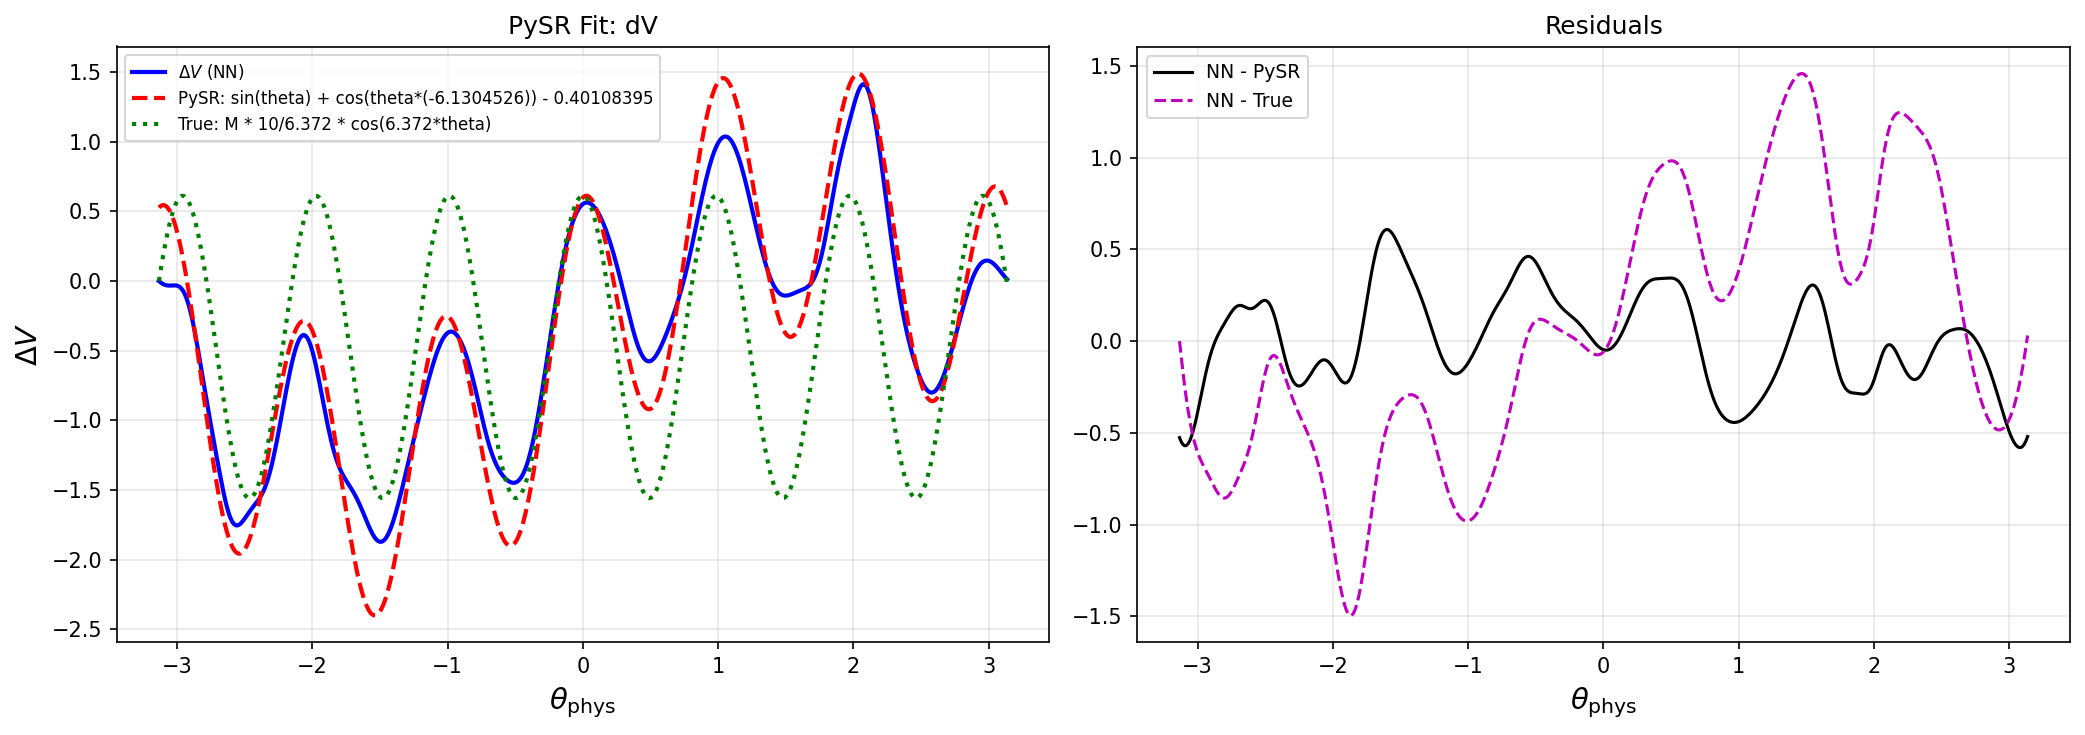


PySR equation table:
    complexity      loss                                                                                                                  equation
0            1  0.668230                                                                                                               -0.37767047
1            2  0.431686                                                                                                                sin(theta)
2            3  0.425019                                                                                                           sin(sin(theta))
3            4  0.287835                                                                                                   sin(theta) + -0.3792602
4            5  0.281296                                                                                               sin(sin(theta)) - 0.3791189
5            6  0.280651                                                                        

In [89]:
from pysr import PySRRegressor

print("=" * 65)
print(f"PySR on dV — {PC['name']}")
print("=" * 65)

sr_dv = PySRRegressor(
    niterations=300,
    binary_operators=PC['pysr_binary'],
    unary_operators=PC['pysr_unary'],
    denoise=False,
    model_selection='best',
    maxsize=20,
    parsimony=0.005,
    populations=30,
    population_size=50,
    ncycles_per_iteration=550,
    weight_optimize=0.001,
    adaptive_parsimony_scaling=1000,
    random_state=42,
    procs=4,
    temp_equation_file=True,
)
sr_dv.fit(X_fit, delta_V_sorted, variable_names=['theta'])

# Select best by max score
eqs_dv = sr_dv.equations_
scores_dv = eqs_dv['score'].values.astype(float)
best_idx_dv = eqs_dv.index[np.argmax(scores_dv)]
expr_dv = sr_dv.sympy(index=best_idx_dv)
pred_dv_pysr = sr_dv.predict(X_fit, index=best_idx_dv)

print(f"\nBest expression: {expr_dv}")
print(f"Complexity: {eqs_dv.loc[best_idx_dv, 'complexity']}")

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5), dpi=DPI)

axes[0].plot(theta_gt, delta_V_sorted, 'b-', lw=2, label=r'$\Delta V$ (NN)')
axes[0].plot(theta_gt, pred_dv_pysr, 'r--', lw=2, label=f'PySR: {expr_dv}')
axes[0].plot(theta_gt, true_delta_V, 'g:', lw=2, label=f'True: {PC["dV_formula"]}')
axes[0].set_xlabel(r'$\theta_{\mathrm{phys}}$', fontsize=14)
axes[0].set_ylabel(r'$\Delta V$', fontsize=14)
axes[0].set_title('PySR Fit: dV')
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.3)

axes[1].plot(theta_gt, delta_V_sorted - pred_dv_pysr, 'k-', lw=1.5, label='NN - PySR')
axes[1].plot(theta_gt, delta_V_sorted - true_delta_V, 'm--', lw=1.5, label='NN - True')
axes[1].set_xlabel(r'$\theta_{\mathrm{phys}}$', fontsize=14)
axes[1].set_title('Residuals')
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nPySR equation table:")
print(sr_dv.equations_[['complexity', 'loss', 'equation']].to_string())

## 7b. Expand PySR Expressions to Standard Polynomial Form

Expand PySR's nested/factored expressions to polynomial coefficients for direct comparison with ground truth.

In [90]:
import sympy as sp

theta_sym = sp.Symbol('theta')

print("=" * 60)
print("PySR EXPRESSION ANALYSIS")
print("=" * 60)

print(f"\n  da best expression: {expr_da}")
print(f"  da expanded:        {sp.expand(expr_da)}")

print(f"\n  dV best expression: {expr_dv}")
print(f"  dV expanded:        {sp.expand(expr_dv)}")

# R2 of PySR predictions vs ground truth
from sklearn.metrics import r2_score
r2_pysr_da_vs_gt = r2_score(true_delta_a, pred_da_pysr)
r2_pysr_dv_vs_gt = r2_score(true_delta_V, pred_dv_pysr)
print(f"\n  R2(PySR da vs true da): {r2_pysr_da_vs_gt:.4f}")
print(f"  R2(PySR dV vs true dV): {r2_pysr_dv_vs_gt:.4f}")

# Full equation tables
print(f"\n--- da equation table ---")
print(sr_da.equations_[['complexity', 'loss', 'equation']].to_string())
print(f"\n--- dV equation table ---")
print(sr_dv.equations_[['complexity', 'loss', 'equation']].to_string())

PySR EXPRESSION ANALYSIS

  da best expression: sin(theta*6.166428)*6.456643
  da expanded:        6.456643*sin(6.166428*theta)

  dV best expression: sin(theta) + cos(theta*(-6.1304526)) - 0.40108395
  dV expanded:        sin(theta) + cos(6.1304526*theta) - 0.40108395

  R2(PySR da vs true da): 0.7774
  R2(PySR dV vs true dV): -0.0084

--- da equation table ---
    complexity       loss                                                                                                             equation
0            1  23.667192                                                                                                        -0.0048866104
1            3  23.594627                                                                                                  theta * -0.14848612
2            4  17.837324                                                                                               sin(theta * 6.1568704)
3            6   3.270973                                      

## 9. Summary

In [91]:
from sklearn.metrics import r2_score

print("=" * 80)
print(f"     SUMMARY REPORT: {PC['name']}")
print("=" * 80)

print(f"\nPerturbation: {PC['name']}")
print(f"  True da = {PC['da_formula']}")
print(f"  True dV (symbolic) = {PC['dV_formula']}")
print(f"  M_scale = {M_scale:.4f}")

# Compute actual numerical dV by evaluating at theta=1 for each power
# true_dV_raw = M * (a1/2 * θ² + a2/3 * θ³ + a3/4 * θ⁴) or similar
# Instead of string manipulation, just evaluate the lambda at unit vectors
# to extract effective coefficients
_t = np.linspace(-np.pi, np.pi, 500)
_dv_vals = PC['true_dV_raw'](_t, M_scale)
_dv_vals_anchored = _dv_vals - _dv_vals[0]
# Fit polynomial to get the actual numerical coefficients
_dv_coeffs = np.polyfit(_t, _dv_vals, PC['poly_deg_dV'])
_terms = []
for j, c in enumerate(_dv_coeffs):
    power = PC['poly_deg_dV'] - j
    if abs(c) > 1e-8:
        _terms.append(f"{c:+.4f}*theta^{power}" if power > 1 else
                      f"{c:+.4f}*theta" if power == 1 else
                      f"{c:+.4f}")
print(f"  True dV (numerical) = {' '.join(_terms)}")

# ---- Signal quality ----
r2_nn_dv = r2_score(true_delta_V, delta_V_sorted)
r2_nn_da = r2_score(true_delta_a, delta_acc_sorted)
print(f"\nNeural Network Signal Quality:")
print(f"  R2(NN dV vs true dV): {r2_nn_dv:.4f}")
print(f"  R2(NN da vs true da): {r2_nn_da:.4f}")

# ============================================================
# 1. Polynomial Regression
# ============================================================
print(f"\n{'='*80}")
print("  1. POLYNOMIAL REGRESSION")
print(f"{'='*80}")

deg_da = PC['poly_deg_da']
deg_dv = PC['poly_deg_dV']
c_da = np.polyfit(theta_gt, delta_acc_sorted, deg_da)
c_dv = np.polyfit(theta_gt, delta_V_sorted, deg_dv)

poly_da_pred = np.polyval(c_da, theta_gt)
poly_dv_pred = np.polyval(c_dv, theta_gt)
r2_poly_da = r2_score(delta_acc_sorted, poly_da_pred)
r2_poly_dv = r2_score(delta_V_sorted, poly_dv_pred)
r2_poly_da_gt = r2_score(true_delta_a, poly_da_pred)
r2_poly_dv_gt = r2_score(true_delta_V, poly_dv_pred)

print(f"\n  da (degree {deg_da}): R2 vs NN = {r2_poly_da:.4f}, R2 vs GT = {r2_poly_da_gt:.4f}")
print(f"  dV (degree {deg_dv}): R2 vs NN = {r2_poly_dv:.4f}, R2 vs GT = {r2_poly_dv_gt:.4f}")

# ============================================================
# 2. SINDy
# ============================================================
print(f"\n{'='*80}")
print("  2. SINDy")
print(f"{'='*80}")

sindy_pred_da = np.array(best_da['model'].predict(X_sindy)).flatten()
sindy_pred_dv = np.array(best_dv['model'].predict(X_sindy)).flatten()
r2_sindy_da_gt = r2_score(true_delta_a, sindy_pred_da)
r2_sindy_dv_gt = r2_score(true_delta_V, sindy_pred_dv)

print(f"\n  da: {best_da['equations'][0]}")
print(f"      R2 vs NN = {best_da['r2']:.4f}, R2 vs GT = {r2_sindy_da_gt:.4f}")
print(f"      {best_da['n_active']} active terms, threshold = {best_da['threshold']:.4f}")
print(f"\n  dV: {best_dv['equations'][0]}")
print(f"      R2 vs NN = {best_dv['r2']:.4f}, R2 vs GT = {r2_sindy_dv_gt:.4f}")
print(f"      {best_dv['n_active']} active terms, threshold = {best_dv['threshold']:.4f}")

# ============================================================
# 3. PySR
# ============================================================
print(f"\n{'='*80}")
print("  3. PySR")
print(f"{'='*80}")

r2_pysr_da_nn = r2_score(delta_acc_sorted, pred_da_pysr)
r2_pysr_dv_nn = r2_score(delta_V_sorted, pred_dv_pysr)
r2_pysr_da_gt = r2_score(true_delta_a, pred_da_pysr)
r2_pysr_dv_gt = r2_score(true_delta_V, pred_dv_pysr)

print(f"\n  da: {expr_da}")
print(f"      R2 vs NN = {r2_pysr_da_nn:.4f}, R2 vs GT = {r2_pysr_da_gt:.4f}")
print(f"\n  dV: {expr_dv}")
print(f"      R2 vs NN = {r2_pysr_dv_nn:.4f}, R2 vs GT = {r2_pysr_dv_gt:.4f}")

# ============================================================
# Comparison Table
# ============================================================
print(f"\n{'='*80}")
print("  METHOD COMPARISON")
print(f"{'='*80}")

print(f"\n  {'Method':<20} {'R2(da vs GT)':>14} {'R2(dV vs GT)':>14}")
print(f"  {'-'*50}")
print(f"  {'NN (raw signal)':<20} {r2_nn_da:>14.4f} {r2_nn_dv:>14.4f}")
print(f"  {'Poly Regression':<20} {r2_poly_da_gt:>14.4f} {r2_poly_dv_gt:>14.4f}")
print(f"  {'SINDy':<20} {r2_sindy_da_gt:>14.4f} {r2_sindy_dv_gt:>14.4f}")
print(f"  {'PySR':<20} {r2_pysr_da_gt:>14.4f} {r2_pysr_dv_gt:>14.4f}")

print(f"\n{'='*80}")

     SUMMARY REPORT: T1: sin(6.372*theta), B=10

Perturbation: T1: sin(6.372*theta), B=10
  True da = 10 * sin(6.372*theta)
  True dV (symbolic) = M * 10/6.372 * cos(6.372*theta)
  M_scale = 0.6915
  True dV (numerical) = +0.0083*theta^6 -0.0898*theta^4 +0.2239*theta^2 -0.0729

Neural Network Signal Quality:
  R2(NN dV vs true dV): 0.0886
  R2(NN da vs true da): 0.7113

  1. POLYNOMIAL REGRESSION

  da (degree 5): R2 vs NN = 0.0570, R2 vs GT = -0.0268
  dV (degree 6): R2 vs NN = 0.6176, R2 vs GT = -0.5999

  2. SINDy

  da: -150.818 1 + -33680.216 theta + 65.587 theta^2 + 4913.787 theta^3 + -3.335 theta^4 + -152.115 theta^5 + 35421.545 sin(1 theta) + 157.828 cos(1 theta) + -1005.357 sin(2 theta) + -9.676 cos(2 theta) + 110.413 sin(3 theta) + 1.864 cos(3 theta) + -18.381 sin(4 theta) + -0.848 cos(4 theta) + 2.636 sin(5 theta) + 0.278 cos(5 theta) + 6.257 sin(6 theta) + -0.524 cos(6 theta) + 0.360 sin(7 theta) + -0.327 cos(7 theta)
      R2 vs NN = 0.9239, R2 vs GT = 0.7488
      20 acti